# 01 · 数据总览与 EDA

> 目标：不靠肉眼，用**统计量 + 图**系统性地回答关于数据的一组问题。

**EDA 的四层问题**

1. **L1 规模/类型**：数据大小对不对？列是什么类型？
2. **L2 目标变量**：`SalePrice` 长什么样？要不要 log 变换？
3. **L3 单特征体检**：每列有没有缺失 / 离群 / 近乎常数？
4. **L4 特征↔目标关系**：哪些特征真正影响房价？

**心法**：逐层缩小范围，最后才对"可疑目标"画图，而不是一上来就画 79 张图。

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
# 让 matplotlib 正常显示中文（Windows 自带字体）
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

# 稳健地定位项目根目录（无论 notebook 从哪运行）
ROOT = Path.cwd()
for p in [ROOT, *ROOT.parents]:
    if (p / "data" / "raw" / "train.csv").exists():
        ROOT = p
        break
print("项目根目录:", ROOT)

train = pd.read_csv(ROOT / "data" / "raw" / "train.csv")
test = pd.read_csv(ROOT / "data" / "raw" / "test.csv")
print("train:", train.shape, "| test:", test.shape)

项目根目录: c:\Users\23353\Desktop\house-prices-kaggle
train: (1460, 81) | test: (1459, 80)


## L1 · 全局概览

先搞清楚：多少行、多少列、哪些是数值、哪些是类别、占多少内存。

In [3]:
num_cols = train.select_dtypes(include="number").columns.tolist()
cat_cols = train.select_dtypes(exclude="number").columns.tolist()
print(f"数值列 {len(num_cols)} 个 | 类别列 {len(cat_cols)} 个")
print(f"内存占用: {train.memory_usage(deep=True).sum()/1024**2:.2f} MB")

overview = pd.DataFrame({
    "dtype": train.dtypes.astype(str),
    "n_unique": train.nunique(),
    "n_missing": train.isna().sum(),
    "missing_pct": (train.isna().mean() * 100).round(1),
})
overview.head(15)

数值列 38 个 | 类别列 43 个
内存占用: 3.43 MB


,dtype,n_unique,n_missing,missing_pct
Id,int64,1460,0,0.0
MSSubClass,int64,15,0,0.0
MSZoning,str,5,0,0.0
LotFrontage,float64,110,259,17.7
LotArea,int64,1073,0,0.0
Street,str,2,0,0.0
Alley,str,2,1369,93.8
LotShape,str,4,0,0.0
LandContour,str,4,0,0.0
Utilities,str,2,0,0.0


## L2 · 目标变量 SalePrice

看分布形态和偏度，决定**要不要对目标做 log 变换**（官方指标就是 RMSE-log）。

count      1460.0
mean     180921.0
std       79443.0
min       34900.0
25%      129975.0
50%      163000.0
75%      214000.0
max      755000.0
Name: SalePrice, dtype: float64

偏度 skew = 1.88  (>0 表示右偏)


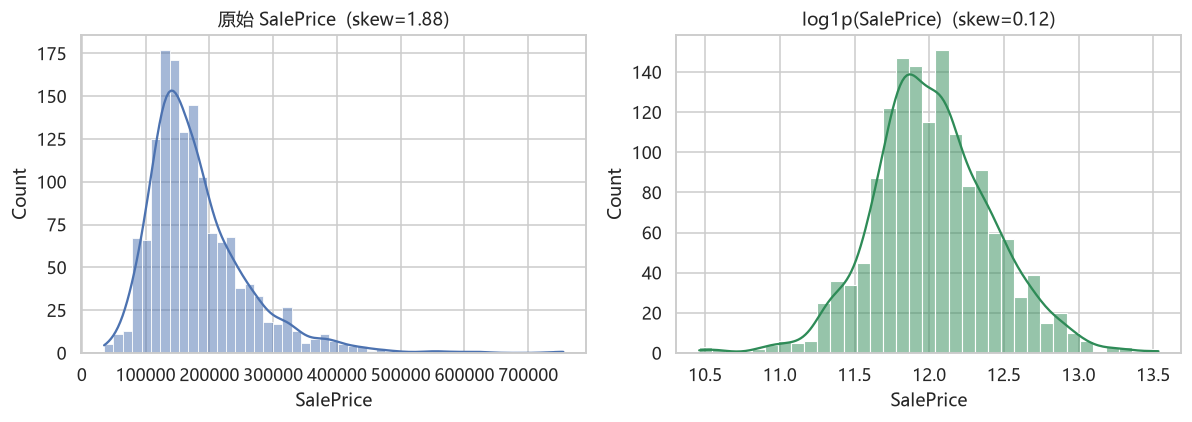

In [6]:
print(train["SalePrice"].describe().round(0))
print(f"\n偏度 skew = {train['SalePrice'].skew():.2f}  (>0 表示右偏)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(train["SalePrice"], kde=True, ax=axes[0])
axes[0].set_title(f"原始 SalePrice  (skew={train['SalePrice'].skew():.2f})")
sns.histplot(np.log1p(train["SalePrice"]), kde=True, ax=axes[1], color="seagreen")
axes[1].set_title(f"log1p(SalePrice)  (skew={np.log1p(train['SalePrice']).skew():.2f})")
plt.tight_layout()
plt.show()

## L3 · 缺失值：区分"真缺失"和"无该设施"

这是本项目**最大的坑**：很多 `NA` 不是数据丢了，而是"没有这个东西"。
判断标准：看数据字典里该字段**是否显式列出了 `NA` 这个取值**。

In [7]:
NA_MEANS_NONE = {
    "PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "MasVnrType",
}

miss = train.isna().sum()
miss = miss[miss > 0].sort_values(ascending=False)
tbl = pd.DataFrame({
    "n_missing": miss,
    "pct": (miss / len(train) * 100).round(1),
})
tbl["NA的含义"] = ["无该设施(填 None)" if c in NA_MEANS_NONE else "真缺失(需统计填补)"
                  for c in tbl.index]
print(f"共 {len(tbl)} 列存在缺失；总缺失格子数 {int(miss.sum())}")
tbl

共 19 列存在缺失；总缺失格子数 7829


,n_missing,pct,NA的含义
PoolQC,1453,99.5,无该设施(填 None)
MiscFeature,1406,96.3,无该设施(填 None)
Alley,1369,93.8,无该设施(填 None)
Fence,1179,80.8,无该设施(填 None)
MasVnrType,872,59.7,无该设施(填 None)
FireplaceQu,690,47.3,无该设施(填 None)
LotFrontage,259,17.7,真缺失(需统计填补)
GarageType,81,5.5,无该设施(填 None)
GarageYrBlt,81,5.5,真缺失(需统计填补)
GarageFinish,81,5.5,无该设施(填 None)


## L3 · 数值特征：偏态排行

右偏严重的特征，线性模型吃不消，通常要做 log/Box-Cox 变换。

In [8]:
skew_num = train[num_cols].skew().sort_values(ascending=False)
print("偏度最高的 12 个特征（右偏严重）：")
print(skew_num.head(12).round(2))

偏度最高的 12 个特征（右偏严重）：
MiscVal          24.48
PoolArea         14.83
LotArea          12.21
3SsnPorch        10.30
LowQualFinSF      9.01
KitchenAbvGr      4.49
BsmtFinSF2        4.26
ScreenPorch       4.12
BsmtHalfBath      4.10
EnclosedPorch     3.09
MasVnrArea        2.67
OpenPorchSF       2.36
dtype: float64


## L3 · 类别特征：基数（唯一值个数）

- 唯一值多 → One-Hot 后维度爆炸（要小心）
- 唯一值 = 1 → 近乎常数，可考虑直接丢弃

In [9]:
card = train[cat_cols].nunique().sort_values(ascending=False)
print("唯一值最多的类别列（One-Hot 后维度膨胀）：")
print(card.head(12))
print("\n唯一值极少的类别列（近乎常数）：")
print(card.tail(8))

唯一值最多的类别列（One-Hot 后维度膨胀）：
Neighborhood    25
Exterior2nd     16
Exterior1st     15
Condition1       9
SaleType         9
HouseStyle       8
RoofMatl         8
Condition2       8
Functional       7
BsmtFinType2     6
RoofStyle        6
BsmtFinType1     6
dtype: int64

唯一值极少的类别列（近乎常数）：
PoolQC          3
GarageFinish    3
PavedDrive      3
MasVnrType      3
Utilities       2
Alley           2
Street          2
CentralAir      2
dtype: int64


## L4 · 与目标的关系：相关性排行

用皮尔逊相关系数快速筛出"最有信号"的数值特征。

In [10]:
corr = train[num_cols].corr()["SalePrice"].drop("SalePrice").sort_values(ascending=False)
print("与 SalePrice 正相关 Top 10：")
print(corr.head(10).round(3))
print("\n与 SalePrice 最不相关 / 负相关 Top 5：")
print(corr.tail(5).round(3))

与 SalePrice 正相关 Top 10：
OverallQual     0.791
GrLivArea       0.709
GarageCars      0.640
GarageArea      0.623
TotalBsmtSF     0.614
1stFlrSF        0.606
FullBath        0.561
TotRmsAbvGrd    0.534
YearBuilt       0.523
YearRemodAdd    0.507
Name: SalePrice, dtype: float64

与 SalePrice 最不相关 / 负相关 Top 5：
YrSold          -0.029
OverallCond     -0.078
MSSubClass      -0.084
EnclosedPorch   -0.129
KitchenAbvGr    -0.136
Name: SalePrice, dtype: float64


## L4 · 关键关系与离群点

`GrLivArea`（地上居住面积）是相关性最高的特征，看它和目标的关系，
顺便抓出明显的离群样本（面积很大但价格很低，通常是异常点）。

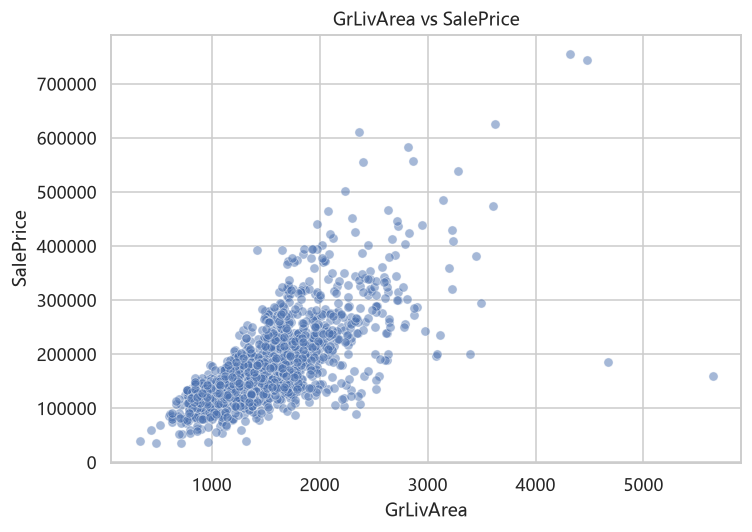

GrLivArea > 4500 的样本数: 2


,Id,GrLivArea,SalePrice,OverallQual
523,524,4676,184750,10
1298,1299,5642,160000,10


In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=train, x="GrLivArea", y="SalePrice", alpha=0.5, ax=ax)
ax.set_title("GrLivArea vs SalePrice")
plt.tight_layout()
plt.show()

outliers = train[train["GrLivArea"] > 4500]
print(f"GrLivArea > 4500 的样本数: {len(outliers)}")
outliers[["Id", "GrLivArea", "SalePrice", "OverallQual"]]

## 结论清单（EDA → 下一步动作）

EDA 的产出**不是图，而是一份可执行的清单**。填完下面这张表，就可以进特征工程了：

| 发现 | 下一步动作 |
|------|-----------|
| `SalePrice` 右偏 | 对目标做 `log1p`，CV 用 RMSE-log |
| 15 列缺失，多为"无设施" | 按语义填 `None`；真缺失用中位数/众数 |
| 部分数值列偏度 > 1 | log 变换或改用树模型 |
| 类别列基数差异大 | 低基数 One-Hot；高基数考虑 target encoding |
| `OverallQual`/`GrLivArea` 相关性高 | 优先保留，并构造交互特征 |
| 发现 `GrLivArea` 离群样本 | 判断是否剔除（先别删，记录待验证） |